## **PART 1**

In [33]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
[3.0, 2.0, 1.0],
[4.0, 1.0, 2.0],
[1.0, 3.0, 2.0],
[2.0, 2.0, 4.0],
[5.0, 0.0, 1.0],
])

X.shape

(5, 3)

### **1. Questions:**
1. What do the rows and columns of 𝑋 represent? What does 𝑋4,2 represent in words?
2. What is the shape of 𝑋? What is the shape of 𝑋𝑣 if 𝑣 ∈ ℝ3?
3. Explain why centering or scaling columns might be useful before comparing observations or finding directions of variation.

### **Answers:**
1. Rows represent the individual vectors while columns represent the numbers in each position of the vector. Going down rows entails the traversal of different vectors while going across columns entails the traversal of the individual entries in a specific vector. X4,2 represents the number in the 4th row and 2nd column of X, which is associated with the second number in the fourth vector in the matrix X.
2. X is a 5 x 3 array. Xv would be 5 x 1 if v ∈ ℝ3.
3. Manipulating columns before comparing observations is important to maintain signal strength. Values across columns can vary in magnitude, and without scaling, columns with consistently large numbers would bury patterns in the columns with smaller magnitude numbers. Thus, centering and scaling allows each column to be compared with equal weight. 


### **2. Questions:**

Let x = [3, 2, 1] and y = [1, 1, 0]. Treat y as a reference pattern involving the first two features. 

1. Compute the projection
$\bm{x_2} = proj_{\bm{y}}(\bm{x}) = \frac {\bm{x}^T\bm{y}}{\bm{y}^T\bm y}$
2. Compute the residual x1 = x - x2.
3. Verify that $ \bm{x}_1^T \bm{y} = 0 $. What does this tell you geometrically?
4. What does x2 measure, and what information remains in x1?

### **Answers:**

1. x2 = [5/2, 5/2, 0].
2. x1 = x - x2 = [3, 2, 1] - [5/2, 5/2, 0] = [1/2, -1/2, 1].
3. $ \bm{x}_1^T \bm{y} = 0 $ --> 1/2 * 1 + -1/2 * 1 + 1 * 0 = 0. This tells us that x1 and y are perpendicular (i.e. they have no component in the same direction). 
4. x2 measures the component of x that is in the same direction as y. x1 contains the remaining portion of the vector, which is not in the direction of y. In other words, x1 is the vector difference between x and x2.


In [34]:
#Use X and reference direction y.

X = np.array([
[3.0, 2.0, 1.0],
[4.0, 1.0, 2.0],
[1.0, 3.0, 2.0],
[2.0, 2.0, 4.0],
[5.0, 0.0, 1.0],
])

y = np.array([1.0, 1.0, 0.0])

### **3. Questions:**

1. Compute the projection coefficient for each row of 𝑋. Store the results in a one-dimensional array.
2. Which observation is most aligned with y? Explain how you decided.
3. Plot the five projection coefficients with labeled axes and a descriptive title.
4. Explain why projection onto a direction can be useful for visualization or summarization.
5. The central dogma describes information flow from DNA to RNA to protein. Give one example
of how a vector of measurements could represent one of these biological objects, and explain your
thinking on if a projection score should be interpreted as an association with a pattern or as proof
of a causal mechanism.
6. In a single-cell RNA-sequencing matrix, what do rows and columns usually represent? Give one
reason cell-level normalization or gene filtering might be needed before computing projection scores.
7. Let b1 and b2 be two linearly independent reference directions. Explain the difference between their
span and a basis for that span. How could projecting onto several directions relate to the SVD $ X = U\Sigma V^T$?

Projection coefficient array: [2.5, 2.5, 2. , 2. , 2.5]
Angles array: [[19.10660535, 39.50971229, 40.89339465, 54.73561032, 46.10211375]]


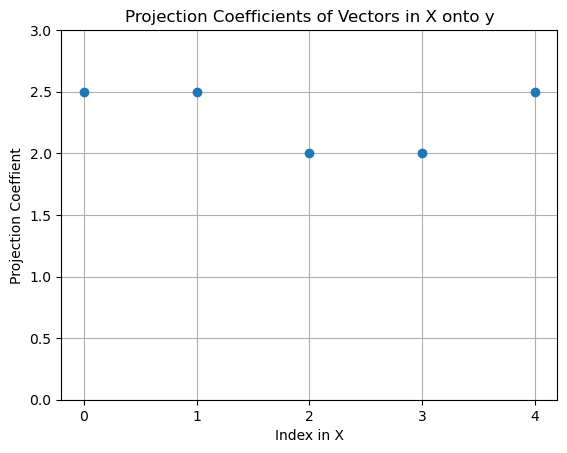

In [35]:
### 
# ANSWERS
###

#1.
denom = np.dot(y, y)
v = np.dot(X, y)
proj_coef = v/denom
proj_coef_print = np.array2string(v/denom, separator=', ')
print(f"Projection coefficient array: {proj_coef_print}")

#2. 
# For each vector v in X, v * y = |x||y|cos(angle)

dotmatrix = X @ y.reshape(-1, 1)

X_mags = np.linalg.norm(X, axis=1, keepdims=True)

cos_angle = dotmatrix / (X_mags * np.linalg.norm(y))

angles_deg = np.array2string((np.degrees(np.arccos(cos_angle))).transpose(), separator=", ")

print(f"Angles array: {angles_deg}")

#The first vector [3.0, 2.0, 1.0] is the most aligned with y. This was determined by calculating the dot product of each vector in X with y, and then dividing those products by the product of the magnitudes to determine the cosine of the angle between them. This employed the property that the dot of vector v and vector y is equal to the product of the magnitudes times the cosine of the angle. Taking the inverse of this value yielded the angle. Since the angle of the 1st vector was closest to 0, it is the one most aligned with y.

#3. 
plt.plot(proj_coef, marker='o', linestyle='none', )
plt.xlabel('Index in X')
plt.xticks([0, 1, 2, 3, 4])
plt.ylabel('Projection Coeffient')
plt.yticks(np.arange(0, 3.5, 0.5))
plt.title('Projection Coefficients of Vectors in X onto y')
plt.grid(True)
plt.show()

#4
#Given some N-dimensional data, there could be a large amount of noise in the  measurements resulting in variation in all different directions. However, if a direction of significance is known from previous knowledge or a similar reason, then projecting the vectors containing the data onto a reference vector in this direction could help filter out the noise and focus on actual signal of importance. In addition, projection onto a direction carefully chosen to capture as much variance in the data as possible can allow for dimensionality reduction, which makes data easier to analyze and visualize while minimizing the information lost. In this way, insights in the data can be highlighted while removing some of the noise and complexity. 

#5
# A vector of measurements can be used to represent RNA counts in single-cell RNA sequencing data. Each element in the vector could represent the count of a different transcribed gene, so the measurements would contain information about the counts of RNA across many cells. A projection score could be calculated from these vectors to try and identify trends in how the number of copies of different RNAs vary with each other. Since data is simply observed from various different cells, any relationship found in the data cannot be attributed to anything in particular. In data science, correlation cannot be interpreted as causation since there could be a variety of other explanations for the relationship. Thus, the score should be interpreted as an association with a pattern instead of as proof of a causal mechanism.

#6
# In a single-cell RNA-sequencing matrix, rows usually representing individual cells while columns represent RNAs transcribed from a specific gene. Cell-level normalization might be required in order to account for biases present in data collection that could also affect bulk RNA counts. Some examples of these include variation in cell type, expression levels, cell size, and total instrument counts. By normalizing the information, RNA counts can be compared across invididuals and analyzed together. 

#7
#Their span is the set of all linear combinations of those two vectors. Since there are two linearly independent vectors, the span is a 2d space with infinite vectors. On the other hand, the basis for the span is any set of linearly indepedent reference directions in that space. B1 and b2 are two linearly independent vectors in that space, so they form a basis for the span. This also means that any set of vectors spanning that space will also only have two vectors. Projecting onto several different directions is the concept upon which SVD is built on. X contains vectors pointing in different directions, and among those vectors there's likely a lot of noise. By finding the directions that capture the most variation in the data and projecting the vectors onto those directions, you can reduce dimensions and find patterns in the data. In the SVD, V captures the orthonormal basis, ranked, containing the directions with the greatest variance, U captures the coordinates in the new directions, and Sigma captures the weight of the vectors in each new direction.

### **4. Questions**

Two observations have feature vectors 𝑎 = (1, 2, 1) and 𝑏 = (10, 20, 10).
1. What do you expect about their cosine similarity? Explain without calculating the exact value.
2. Would Euclidean distance and cosine similarity emphasize the same aspect of these observations?
Why or why not?
3. Give one biomedical situation in which direction matters more than magnitude, and one in which
magnitude is scientifically important

### **Answers**

1. I expect their cosine similarity to be 1 since b is a scalar multiple of a. We have the relationship 10a = b, so although the magnitudes of the two vectors differ, their direction is the same. The cosine of the angle between them should be 0, and cos(0) = 1.
2. No, Euclidean distance would indicate some degree of separation between the two vectors since it measures the distance between the two endpoints of the vectors. Since a and b have different magnitudes, they would have a non-zero Euclidean distance between them. Only identical vectors would have a Euclidean distance of 0. On the other hand, cosine similarity only emphasizes the difference in direction of the vectors. By having the same direction, the two vectors would show a cosine similarity of 1, indicating perfect similiarity, without necessarily being identical. 
3. When measuring gene expression with RNA-Seq data in cells across different species, the direction of the feature vectors matters more than the magnitude since there could be inherent differences in the amount of overall RNA produced by the cells. These differences could come from differences in the promoters, cell size, or other factors. However, analyzing the direction provides insights about how gene expression varies relative to each other, providing more valuable data about gene activity. In an experiment measuring gene expression in the same way except in an homogenous cell line, magnitude would matter because any differences in overall RNA counts could be attributed to treatment types or phenotypic changes.

## **PART 2**

**A two-state weighted average and variance**

Suppose a randomly selected cell comes from one of two states. State 𝐴 occurs with probability 0.60
and state 𝐵 occurs with probability 0.40. A marker is detected with probability 0.80 in state 𝐴 and
probability 0.20 in state 𝐵. Let 𝑌 = 1 when the marker is detected and 𝑌 = 0 otherwise.

### **5. Questions**
1. Calculate the overall probability 𝑃 (𝑌 = 1) as a probability-weighted average over the two states.
2. Calculate 𝐸[𝑌] and 𝐸[𝑌^2] from the two possible values of 𝑌 .
3. Use Var(𝑌) = 𝐸[𝑌^2] − 𝐸[𝑌]^2 to calculate the variance. Explain why the variance is not obtained
by simply averaging the two state-specific probabilities.
4. How would the overall probability and variance change if state 𝐴 became more common?

### **Answers**
1. $P(Y = 1) = P(Y = 1 | State A) * P(State A) + P(Y = 1 | State B) * P(State B)$

    --> $P(Y = 1) = 0.8 * 0.6 + 0.2 * 0.4 = 0.48 + 0.08 = 0.56$

    --> $P(Y = 1) = 0.56$

2. $P(Y = 1) = 0.56   --> P(Y = 0) = 1 - P(Y = 1) = 0.44$

    --> $E[Y] = 1 * 0.56 + 0 * 0.44 = 0.56$

    --> $E[Y^2] = 1^2 * 0.56 + 0^2 * 0.44 = 0.56$

3. $Var(Y) = E[Y^2] - E[Y]^2 = 0.56 - 0.56^2 = 0.56 - 0.3136 = 0.2464$

    The variance is a measure of the spread or uncertainty of the data, so relating it to just raw probabilities does not capture this information. The average of the two state-specific probabilities does not capture any meaningful information since the states themselves have different probabilities, so a weighted average would be required to get any information about the value of Y. This information would then relate to the mean, but variance would still need to be calculated from other values.

4. If state A became more common, observations would appear to align with the probabilities in state A more than state B since more cells would be in state A. This would push the overall probability closer to that of state A, which is 0.8 (i.e. marker is detected more often). With state A becoming more common, the expected value of Y increases since the probability of marker detection increases. A higher expected value corresponds to higher E[Y^2] and E[Y]^2 terms, but since E[Y]^2 increases more, the variance decreases.


**Poisson versus over-dispersed single-cell counts**

Single-cell RNA-sequencing counts are often initially compared with a Poisson model, for which the mean
and variance are both 𝜆. Consider the following observed counts for one gene across cells:

`gene_counts = np.array([0, 0, 1, 1, 2, 2, 3, 4, 8, 12, 15, 20])`

### **6. Questions**
1. Calculate the sample mean, sample variance, and Fano factor 𝑠^2/x.
2. Does the Poisson mean-variance relationship appear plausible for these data? Explain what feature
of the counts supports your answer.
3. Give at least two biological or technical reasons why single-cell counts might be over-dispersed
relative to a Poisson model.
4. Why is over-dispersion a modeling concern for standard errors or likelihood-based conclusions?
5. Suggest one next step: for example, a negative-binomial model, a transformation, or a model with
cell-level covariates. Explain what problem your choice is intended to address.

In [36]:
gene_counts = np.array([0, 0, 1, 1, 2, 2, 3, 4, 8, 12, 15, 20])

### 
# Answers
###

#1
#The sample mean is the average of all the values, which is 5.667. The sample variance is 40.222. The Fano factor is 40.222/5.667 = 7.098. 
mean = np.mean(gene_counts)
print(mean)
variance = np.var(gene_counts)
print(variance)
print(variance/mean)

#2
#This data does not fit a Poisson mean-variance relationship because in a Poisson distribution, the mean and variance are identical. However, according to the data, the mean is 5.667 while the variance is 40.222, which are significantly different. 

#3
#One reason single-cell counts can be over-dispersed relative to a Poisson model is that cells could be of different types or in different states, leading to large differences in gene expression rates. These large differences could drive variance higher than the mean. Another reason is that many genes are expressed cyclically or in bursts instead of remaining expressed at a constant rate. As a result, cells could have different gene expression amounts at any snapshot in time, leading to increased variance compared to a Poisson distribution.

#4
#Over-dispersion is a concern for standard errors since the assumption of a Poisson distribution can cause the variance to be underestimated. This underestimation could then lead to inflated test statistics that make results appear overly significant. Underestimated standard errors makes expected observations appear closer than they should be in reality. With likelihood-based conclusions, over-dispersion would make the observations appear much less likely than they actually are. When estimating the parameter lambda, the sample mean could be used but result in many observations seeming to be more unusual than they actually are.

#5
#A possible next step is to fit a negative-binomial model instead of a regular Poisson distribution. The issue with Poisson was that it assumes the expression rate of every cell is fixed and identical, but by allowing the rate itself to vary, following a gamma distribution, the additional variance from cells being in different expression states is captured. This addresses the over-dispersion issue by increasing variance to account for differences between cells. 

5.666666666666667
40.22222222222222
7.098039215686274


Consider measurements of a normalized continuous biomarker:

`biomarker = np.array([8.7, 9.4, 10.1, 10.3, 10.8, 11.0, 11.2, 11.9, 12.4, 13.1])`

Assume 𝑋 ∼ 𝒩(𝜇, 𝜎^2) as a first approximation.

### **7. Questions**
1. Compute the sample mean and sample standard deviation. What do these summarize?
2. Plot a histogram and overlay a Gaussian density using your estimated mean and standard deviation.
3. Use the empirical distribution or the Gaussian approximation to estimate the probability that a future measurement is below 10.
4. Identify one reason the Gaussian model may be useful here and one reason it may be inadequate.
5. Explain how the Central Limit Theorem differs from the claim that the individual measurements themselves are Gaussian.

Mean: 10.89 
Std: 1.35


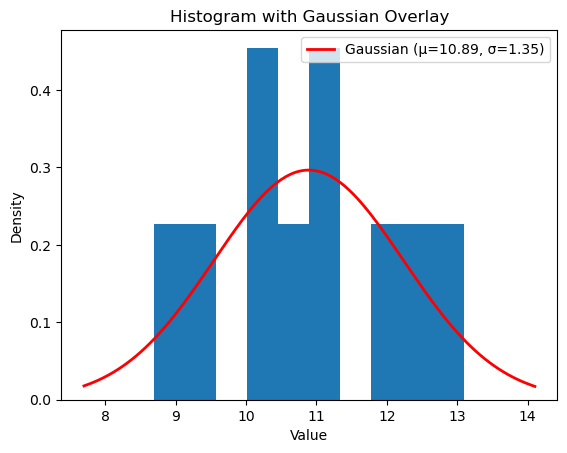

P(X < 10) ≈ 0.2541


In [37]:
biomarker = np.array([8.7, 9.4, 10.1, 10.3, 10.8, 11.0, 11.2, 11.9, 12.4, 13.1])

###
# Answers
###

#1. 
sample_mean = np.mean(biomarker)
sample_std = np.sqrt(np.var(biomarker, ddof = 1))
print(f"Mean: {sample_mean:.2f} \nStd: {sample_std:.2f}")
#These summarize the average value of the observed data and how much, on average, the data tends to differ from the sample average. They provide basic metrics for the observed data.

#2. 
from scipy.stats import norm

plt.hist(biomarker, density=True)
x_vals = np.linspace(min(biomarker)-1, max(biomarker)+1, 200)
plt.plot(x_vals, norm.pdf(x_vals, loc=sample_mean, scale=sample_std), 'r-', lw=2, label=f'Gaussian (μ={sample_mean}, σ={sample_std:.2f})')

plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.title('Histogram with Gaussian Overlay')
plt.show()

#3.
prob_below_10 = norm.cdf(10, loc=sample_mean, scale=sample_std)
print(f"P(X < 10) ≈ {prob_below_10:.4f}")
#The probability of a future measurement less than 10 is 0.2541.

#4.
#The Gaussian model could be useful here because we have continuous data, and a Gaussian model allows for easy calculations of cdfs to analyze probabilities of future observations. It is also a simple model, that roughly captures the shape of the histogram. On the flip side, since our data only has 10 data points, it cannot be confidently concluded that the population follows a normal distribution. There is not enough information to attribute the shape to a normal population distribution. 

#5. 
#The Central Limit Theorem works on the fact that random samples of any population distribution converge to a normal distribution at high enough sample sizes (n=30). Individual measurements would tend the reflect the population distribution, with increased precision as the number of measurements increase. However, the population distribution is not guaranteed to be normal, and in many cases it isn't, which is why the claim that individual measurements are Gaussian is often false. However, samples of many individual measurements tend to cluster around an average value since the sample mean itself is the average of the individual measurements. Thus, the sample means follow a normal distribution, which is what the Central Limit Theorem conveys.


Suppose a condition is present in 2% of a population. A screening test has 90% sensitivity and 95%
specificity.

### **8. Questions**
1. Construct a two-by-two table for 10,000 people showing condition status and test result.
2. Calculate 𝑃 (condition ∣ positive).
3. Identify the conditional probabilities corresponding to sensitivity and specificity. Why are they not
the same as the predictive value?
4. Explain how the base rate affects interpretation of a positive test.

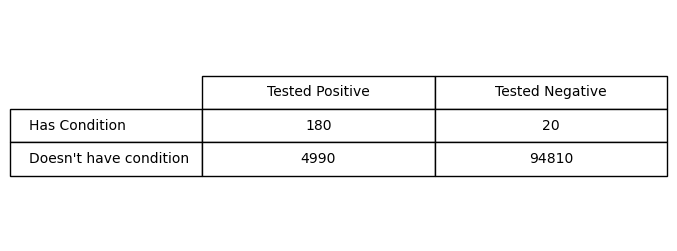

In [38]:
###
# ANSWERS
###

#1. 
# 2% prevalence means for 10,000 people, 200 have it and 99800 don't.
# 90% sensitive means for 200 people that have it, 200*0.9 = 180 are diagnosed true. 
# 95% specificity means for 99800 people that don't it, 99800*0.05 = 4990 are diagnosed true.
# 180 have and true, 20 have and false, 4990 don't have and true, 94,810 don't have and false

data = (['180', '20'], ['4990', '94810'])
columns = ('Tested Positive', 'Tested Negative')
rows = ("Has Condition", "Doesn't have condition")

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=data,
    rowLabels=rows,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)
table.scale(1,2)
plt.show()

#2.
#P(condition | positive) = 180 / (180 + 4990) = 0.0348

#3. 
#Sensitivity corresponds to P(positive | condition) and specificity corresponds to P(negative | no condition). The predictive value is different because the condition is the opposite. Since the predictive value is the probability of condition state given the test result instead of the probability of a test result given the condition state, the value differs. They are metrics of different things. The values are especially different in this case since the population with the condition is so low. With such a low prevalence, there are very few positives to contribute to true positives, so even a low false positive rate leads to more false positives than true positives with a larger population without the condition. 

#4. 
#This ties into the previous question. The base rate of prevalence influences the magnitude of the difference in the number of people with the condition and without. When the base rate tends towards an extreme, where a great majority of people have it or don't have it, then the test results have lower predictive power. With a high base rate, then there will be more people with the condition, so a positive test could be more confidently associated with a true positive. However, with a low base rate, there will be more people without the condition, and even a small false-positive rate would result in a larger number of false-positives than true positives. Thus, a positive result would not as confidently imply that someone actually has the condition.  

## **PART 3**

Suppose each patient either responds or does not respond to a treatment. The observed outcomes are:
`responses = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0])`

Assume 𝑌𝑖 ∼ Bernoulli(𝑝) independently, where 𝑝 is the probability of response.

### **9. Questions**
1. Write the likelihood 𝐿(𝑝 ∣ 𝑦1, … , 𝑦𝑛) as a product of Bernoulli probabilities.
2. Rewrite the likelihood using only the number of responses 𝑘 = ∑𝑖 𝑦𝑖 and the sample size 𝑛.
3. Derive the log-likelihood, dropping terms that do not depend on 𝑝:

ℓ(𝑝) = 𝑘 log 𝑝 + (𝑛 − 𝑘) log(1 − 𝑝) + constant

4. Calculate the MLÊ 𝑝_MLE. Explain why it equals the observed response proportion.
5. Plot the likelihood or log-likelihood over 0 < 𝑝 < 1. What does the plot show about the estimate?



<img src="https://raw.githubusercontent.com/kolluashrith/Biomedical-Data-Science/refs/heads/main/lab1/BDSLab1_Q9Written.png" width="1000"/>

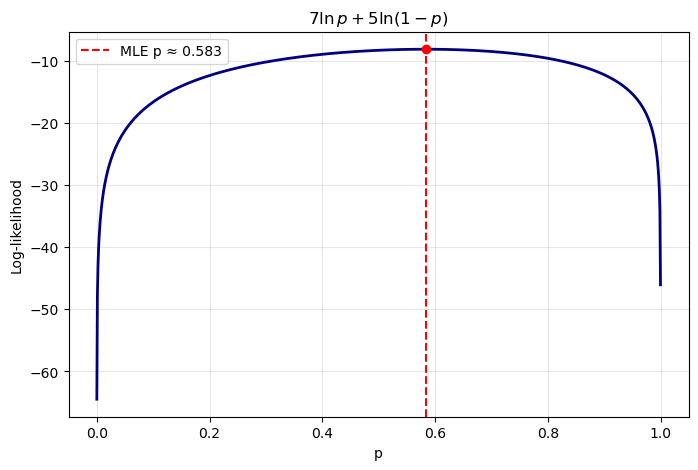

In [39]:
#5. 
# Define p range (avoid exact 0 and 1 since ln(0) is undefined)
p = np.linspace(1e-4, 1 - 1e-4, 1000)

# Log-likelihood function
log_likelihood = 7 * np.log(p) + (12 - 7) * np.log(1 - p)

# Find the max log-likelihood value
max_ll = np.max(log_likelihood)

plt.figure(figsize=(8, 5))
plt.plot(p, log_likelihood, lw=2, color='navy')
plt.axvline(7/12, color='red', linestyle='--', label=f'MLE p ≈ {7/12:.3f}')
plt.scatter(7/12, [max_ll], color='red', zorder=5)

plt.xlabel('p')
plt.ylabel('Log-likelihood')
plt.title(r'$7\ln p + 5\ln(1-p)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#This plot shows that the estimate does, indeed, maximize the log-likelihood. All other p-values result in a log-likelihood value thats lower than that of the estimate. 

<img src="https://raw.githubusercontent.com/kolluashrith/Biomedical-Data-Science/refs/heads/main/lab1/BDSLab1_Q10Written.png" width = 1000>

<img src="https://raw.githubusercontent.com/kolluashrith/Biomedical-Data-Science/refs/heads/main/lab1/BDSLab1_Q11Written.png" width=1000/>

In [40]:
#4.
def J(t):
    return ((t - 3)**2)

def doGradient(n):
    theta = 0

    print(f"Performing gradient descent with learning rate {n}: \n")
    print(f"Theta(0) = {theta}, J(theta_0) = {J(theta):.3f}")
    for i in range(1, 5):
        theta = theta - 2*n*(theta - 3)

        if i < 5:
            print(f"Theta({i}) = {theta:.3f}, J(theta_{i}) = {J(theta):.3f}")
    print("\n\n")

doGradient(0.1)

#5.
doGradient(1.1)

#This time, with a learning rate of 1.1, the gradient descent updates too much every cycle, resulting in oscillations instead of stable convergence. Theta bounces around 3 without actually converging; instead, it appears to diverge. With a learning rate of 0.1, we could actually see J decreasing and theta approaching the minimizing value. This shows that choosing an optimal learning rate is critical to ensure stability and convergence. A small learning rate ensures stability and convergence at the cost of slow descent. Many cycles are required to get close to the minimizing value, so stable performance comes at the cost of time. On the other hand, a large learning rate can allow for quick descent, but it sacrifices stability and could prevent convergence.


Performing gradient descent with learning rate 0.1: 

Theta(0) = 0, J(theta_0) = 9.000
Theta(1) = 0.600, J(theta_1) = 5.760
Theta(2) = 1.080, J(theta_2) = 3.686
Theta(3) = 1.464, J(theta_3) = 2.359
Theta(4) = 1.771, J(theta_4) = 1.510



Performing gradient descent with learning rate 1.1: 

Theta(0) = 0, J(theta_0) = 9.000
Theta(1) = 6.600, J(theta_1) = 12.960
Theta(2) = -1.320, J(theta_2) = 18.662
Theta(3) = 8.184, J(theta_3) = 26.874
Theta(4) = -3.221, J(theta_4) = 38.698





Use the response vector from Question 9. The fitted Bernoulli probability is the sample proportion.

### **12. Questions**
1. Write code for a bootstrap procedure that resamples patients with replacement, refits the response
proportion, and repeats.
2. Implement at least 5,000 resamples and plot the bootstrap distribution of fitted proportions. Mark
the observed sample proportion.
3. Calculate a central 95% bootstrap interval using the 2.5th and 97.5th percentiles.
4. Interpret the interval in terms of repeated sampling. What does it not tell you?
5. What assumptions are being made when patients are resampled independently? Give one situation
in which that assumption would be questionable.

Observed sample proportion: 0.5833
Bootstrap mean proportion:  0.5838


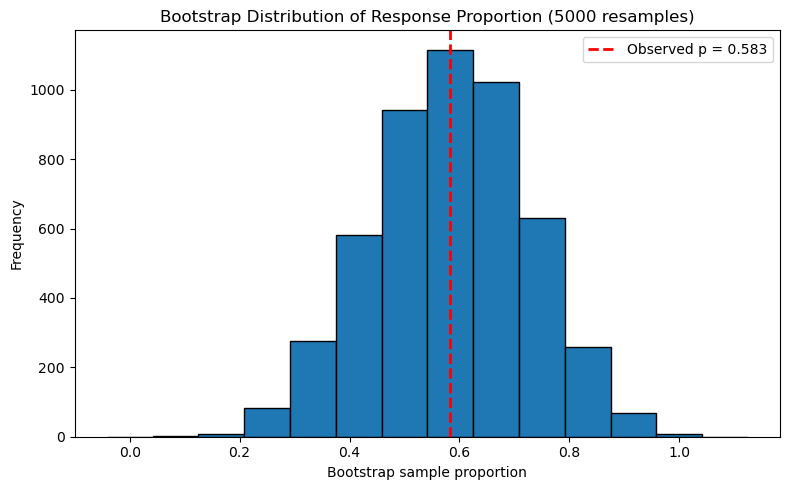

95% Bootstrap CI: [0.3333, 0.8333]


In [41]:
###
# ANSWERS
###

responses = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0])

#1. 

def bootstrap(data, n_boot):

    n = len(data)
    boot_props = np.empty(n_boot)

    for i in range(n_boot):
        #Collect n random entries
        resample = np.random.choice(data, size=n, replace=True)

        #Recalculate mean and add to array
        boot_props[i] = resample.mean()

    return boot_props

#2. 
collected_props = bootstrap(responses, 5000)
observed_p = responses.mean()          # 0.583

print(f"Observed sample proportion: {observed_p:.4f}")
print(f"Bootstrap mean proportion:  {collected_props.mean():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(collected_props, bins=np.arange(-0.5/len(responses), 1.2, 1/len(responses)), edgecolor="black")
plt.axvline(observed_p, color='red', linestyle='--', linewidth=2, label=f'Observed p = {observed_p:.3f}')
plt.xlabel('Bootstrap sample proportion')
plt.ylabel('Frequency')
plt.title(f'Bootstrap Distribution of Response Proportion (5000 resamples)')
plt.legend()
plt.tight_layout()
plt.show()


#3
ci_lower, ci_upper = np.percentile(collected_props, [2.5, 97.5])
print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

#4
#Bootstrap sampling approximates the results that are expected if samples were taken from the actual population instead. The 95% confidence interval from the bootstrapped samples tell us that if we pulled samples of the same size from the actual population, i.e. a bunch of random samples of 12 data points from the population, we would expect 95% of the intervals calculated in the same way to contain the true population mean. The interval itself gives us an idea of where the population proportion might be: in between 0.3333 and 0.8333. It does not tell us the probability that the true population proportion lies in the interval, nor does it tell us anything about the biases in the sampling. It also does not tell us about what to expect for subsequent observations.

#5. 
#With independent resampling, we are making several assumptions about whether or not the sample can be used to stand-in for the population. For one, we are assuming that the sample is representative of the population. If there is some bias in the sample, then we would no longer have a sample representative of the population, resulting in biased bootstrap sampling results too. Independent resampling also works off of the assumption that each patient's response is independent of each other. For example, if the sample in question came from a single hospital and the population is all patients with the treatment, then we could have a significant amount of bias in our sample. The location of the people, hospital quality, and other external factors could all affect the results. Thus, the sample might not be representative of the population, and so independent resampling would keep any bias that may exist. 



## **FINAL SYNTHESIS**

### **13. Questions**

Choose one result from this lab and write a short paragraph addressing:
1. What scientific or measurement question were you asking?
2. What data representation or probability model did you use?
3. What quantity did you estimate or compare?
4. What uncertainty or limitation should accompany your conclusion?
5. What additional data would make the conclusion more reliable?


### **Answer**

From question 9, we were interested in finding the most likely parameter for the probability of response given 12 patients' response data. To calculate this parameter, we used the maximum likelihood estimator (MLE) to find the parameter that made the observed results most likely. We estimated the probability of response, p, across all patients. Although we found the most likely probability to be about 0.583, it is worth noting that patients' response probability is likely based on other factors too, such as genetics and prior health conditions. Thus, though we estimated the probability of response to be a value, it is very likely that the probability changes from patient to patient and is itself a random variable. Estimating the parameter across many other samples with more individuals, and potentially conducting a significance test, would make the conclusion more reliable by providing more data supporting that the probability is, indeed, constant across the population and is close to the estimated value. Analyzing covarience with other health measurements would also be good to identify any other lurking variables affecting our results.

### **14. Questions**

Answer briefly:
1. Which concept was most intuitive, and why?
2. Which concept remains unclear?
3. Describe one connection between linear algebra, probability, and statistical inference that became clearer through the lab

### **Answers**

1. The idea of calculating projections and using them to transform data was intutitive because it was easy to understand the math behind and the reasoning behind why it's beneficial in the way that it is. It was easy to understand how it could remove noise and make results easier to analyze. 
2. I am still unclear about how the Poisson distribution is used with single-cell RNA-sequencing counts. I just can't seem to wrap my head around the reasoning behind using that distribution by default; or any other distribution for that matter. I would've expected the data to be analyzed and a distribution to be fitted based on that instead of having a preset one.
3. The connection behind linear algebra and data analysis was made clear with the discussion about projections and comparisions of cosine similarity and Euclidean distance. The way linear algebra could be used to clean up data to reduce noise and analyze a signal made sense, while the application of basic concepts in higher-dimensions made it easier to understand how to work with multi-dimensional data.